In [56]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [57]:
# filter for the job titles and country
df_Canada = df[(df['job_country'] == 'Canada')].dropna(subset=['salary_year_avg'])

In [58]:
job_titles = df_Canada['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Senior Data Engineer',
 'Data Scientist',
 'Machine Learning Engineer',
 'Software Engineer',
 'Data Analyst']

In [59]:
df_Canada_top6 = df_Canada[df_Canada['job_title_short'].isin(job_titles)]

In [60]:
job_order = df_Canada_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

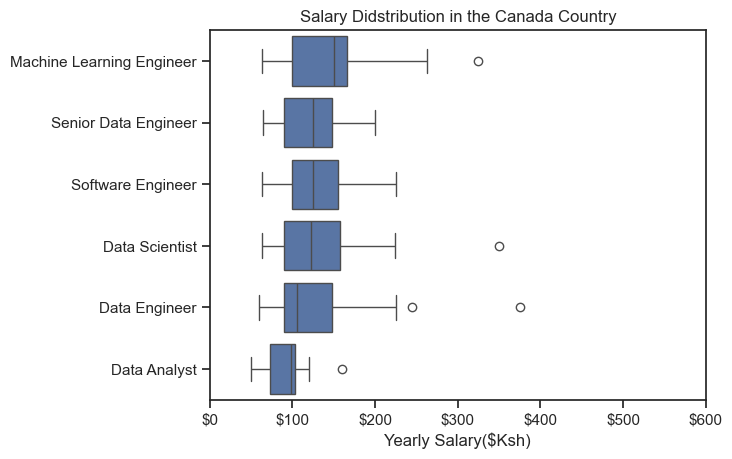

In [61]:
sns.boxplot(data=df_Canada_top6, x='salary_year_avg',y='job_title_short', order= job_order)
sns.set_theme(style='ticks')



plt.title('Salary Didstribution in the Canada Country')
plt.xlabel('Yearly Salary($Ksh)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}'))
plt.xlim(0,600000)
plt.show()

Investigate Median Salary  Vs Skill for Data Analysts

In [62]:
# 1. Filter Data Engineer jobs in Canada
df_DE_Canada = df[
    (df['job_title_short'] == 'Data Engineer') & 
    (df['job_country'] == 'Canada')
].copy()

# 2. Drop rows with missing salary
df_DE_Canada = df_DE_Canada.dropna(subset=['salary_year_avg'])

print(f"Total Data Engineer jobs in Canada with salary: {len(df_DE_Canada)}")
df_DE_Canada[['job_title_short', 'salary_year_avg', 'job_skills']].head()

Total Data Engineer jobs in Canada with salary: 167


,job_title_short,salary_year_avg,job_skills
10270,Data Engineer,125000.0,"[golang, kotlin, scala, python, aws, azure, gc..."
25962,Data Engineer,100000.0,"[python, sql, aws, redshift, snowflake]"
35491,Data Engineer,110000.0,"[sql, c#, python, aws, redshift, pyspark, ssis]"
40698,Data Engineer,101014.0,"[python, sql, watson, aws, ibm cloud, pyspark,..."
40840,Data Engineer,90000.0,"[java, python]"


In [63]:
# Explode the skills column
df_DE_Canada_exploded = df_DE_Canada.explode('job_skills')

# Check the result
df_DE_Canada_exploded[['salary_year_avg', 'job_skills']].head(10)

,salary_year_avg,job_skills
10270,125000.0,golang
10270,125000.0,kotlin
10270,125000.0,scala
10270,125000.0,python
10270,125000.0,aws
10270,125000.0,azure
10270,125000.0,gcp
10270,125000.0,kafka
10270,125000.0,node.js
10270,125000.0,redhat


In [64]:
# Should already have this from before
df_DE_Canada = df[df['job_country'] == 'Canada']

# Or if filtering by job title too
df_DE_Canada = df[(df['job_country'] == 'Canada') & 
                  (df['job_title_short'] == 'Data Engineer')]

In [65]:
# Explode the list column into individual rows first
df_DE_Canada_exploded = df_DE_Canada.explode('job_skills')

# Then group by
df_DE_top_pay = df_DE_Canada_exploded.groupby('job_skills')['salary_year_avg'] \
                                     .agg(['count', 'median']) \
                                     .sort_values(by='median', ascending=False)

df_DE_top_pay = df_DE_top_pay.head(10)
df_DE_top_pay

,count,median
job_skills,,
mongo,1,211000.0
keras,1,175000.0
no-sql,3,175000.0
ubuntu,1,175000.0
seaborn,1,175000.0
rust,1,161875.0
dax,3,155904.5
unify,1,147500.0
excel,11,147500.0


In [66]:
df_DE_Canada_exploded = df_DE_Canada.explode('job_skills')

df_DE_skills = df_DE_Canada_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count',ascending=False).head(10)

df_DE_skills



,count,median
job_skills,,
sql,114,102550.5
python,112,100000.0
aws,87,125000.0
spark,58,102500.0
azure,56,94575.0
kafka,44,100000.0
snowflake,43,125000.0
java,43,107500.0
hadoop,34,112500.0


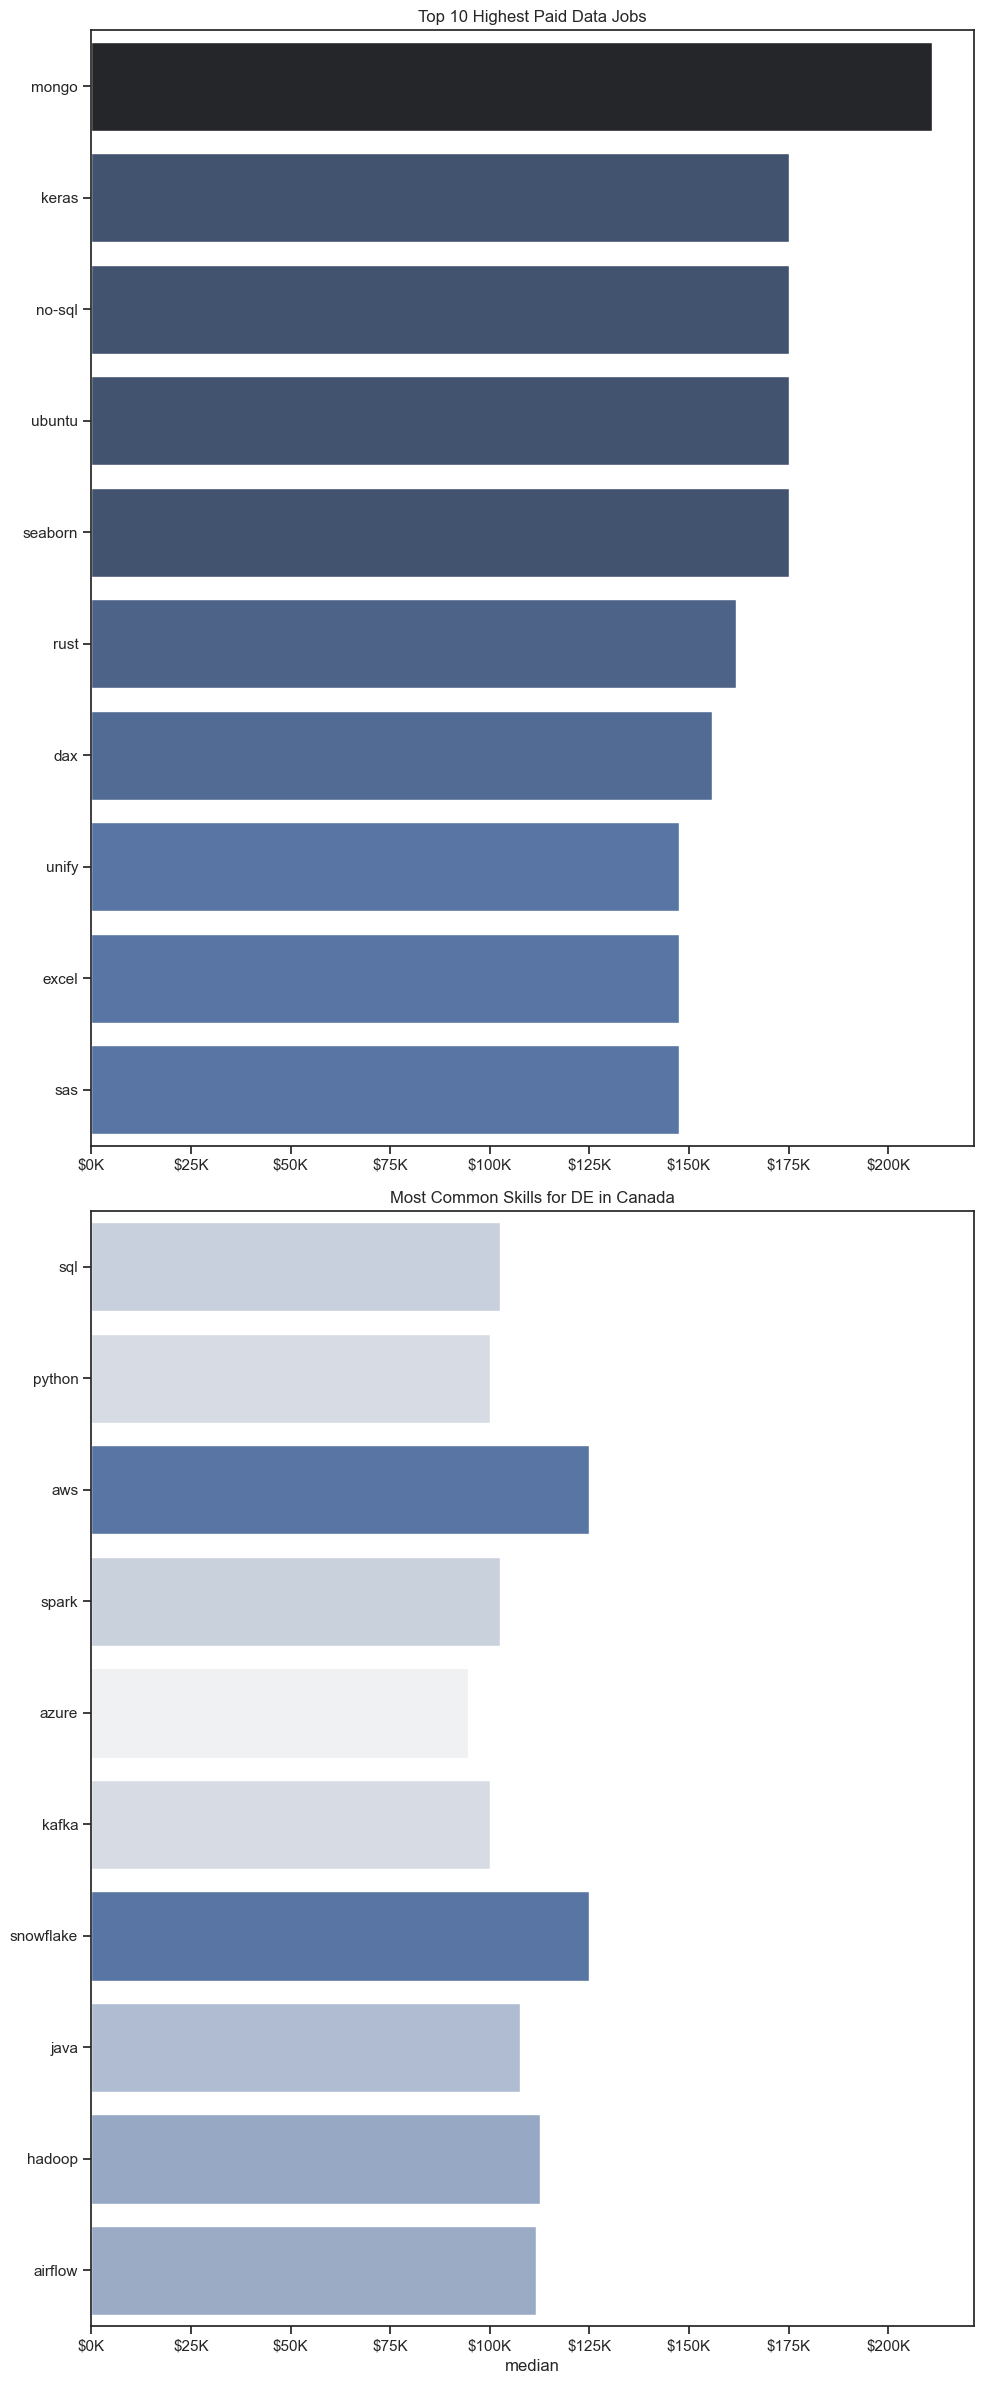

In [70]:
fig, ax = plt.subplots(2, 1, figsize=(10, 24))

sns.set_theme(style="ticks")

# Top 10 Highest Paid skills in DE 
sns.barplot(data=df_DE_top_pay, x='median', y=df_DE_top_pay.index, ax=ax[0],hue='median',palette='dark:b_r')
ax[0].legend().remove()

ax[0].set_title('Top 10 Highest Paid Data Jobs')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

sns.barplot(data=df_DE_skills, x='median', y=df_DE_skills.index, ax=ax[1],hue='median',palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Most Common Skills for DE in Canada')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))  # ✅

plt.tight_layout()
plt.show()